In [16]:
import sys

import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
import data_degrading as dg
import abcsn_training
import abcsn_config
import data_preparation as dp
import preprocessing as pp


sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_project")
from plot_data import *
from process_data import *


from snid_sage.snid import preprocessing as snid_pp 


## reading in data to plot

In [17]:
filenames = glob.glob("/lustre/lrspec/users/4301/Milligan_ABC-SN/data/folder_parquet/*_rebinned.parquet")

In [18]:
master_df = pd.DataFrame()
for file in filenames:
    temp_df = pd.read_parquet(file)
    # print(file.split("/")[-1], ":", len(temp_df))
    master_df = pd.concat([master_df, temp_df], ignore_index=True)

In [19]:
master_df.head()

,ABC_type,Mill_type,SN_mag,Spectral Phase,host,host_mag,redshift,sn_type,2512.529050300541,2537.7127325827696,...,9096.145837554206,9187.318692546025,9279.405394966827,9372.415104528947,9466.357072754703,9561.240643896645,9657.075255867012,9753.870441176497,9851.635827882466,9950.38114054659
0,NaN,3.0,20.361,0.0,sc,24.082,0.62294,SL,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,NaN,3.0,20.486,0.0,sc,22.607,0.55268,SL,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,NaN,3.0,20.504,0.0,sc,23.722,0.54784,SL,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,NaN,3.0,20.516,0.0,sc,25.512,0.94099,SL,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,NaN,3.0,20.545,0.0,sc,25.310,0.99774,SL,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
# correcting ABC_types so that Iap is categorized as Ia-91T
ABC_type = [get_ABC_Mill_type(i)[0] for i in master_df.sn_type]
master_df.ABC_type = ABC_type

In [5]:
data = dp.extract_dataframe(master_df)
index = data[0]  # SN Name for each spectrum
wvl = data[1]  # Wavelength array
flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
df_metadata = data[5]  # Sub-dataframe containing only the metadata
fluxes0 = data[6]  # Only the flux values in a numpy array

X_all = fluxes0

In [25]:
X_all = fluxes0.copy()

flux_start, flux_stop = 59, 103

# Normalize only the selected columns
avg_X = np.average(X_all[:, flux_start:flux_stop], axis=1)
std_X = np.std(X_all[:, flux_start:flux_stop], axis=1)

# Normalize the selected columns
X_all[:, flux_start:flux_stop] -= avg_X[:, np.newaxis]
X_all[:, flux_start:flux_stop] /= std_X[:, np.newaxis]

In [26]:
# putting normalized data back into the dataframe 
master_df[flux0_columns] = X_all

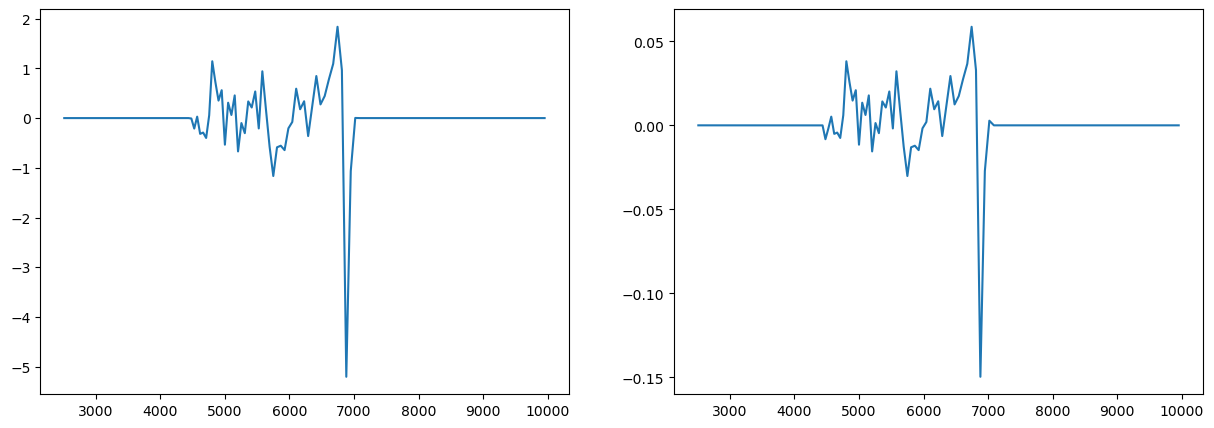

In [7]:
# Checking normalization 
i =-1
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5)) # Adjust figsize as needed
axes[0].plot(wvl, X_all[i], alpha = 1)
axes[1].plot(wvl, fluxes0[i], alpha = 1)

In [27]:
master_df.to_parquet(os.path.join("/lustre/lrspec/users/4301/Milligan_ABC-SN/data/full_preprocessed_dataframe.parquet"))

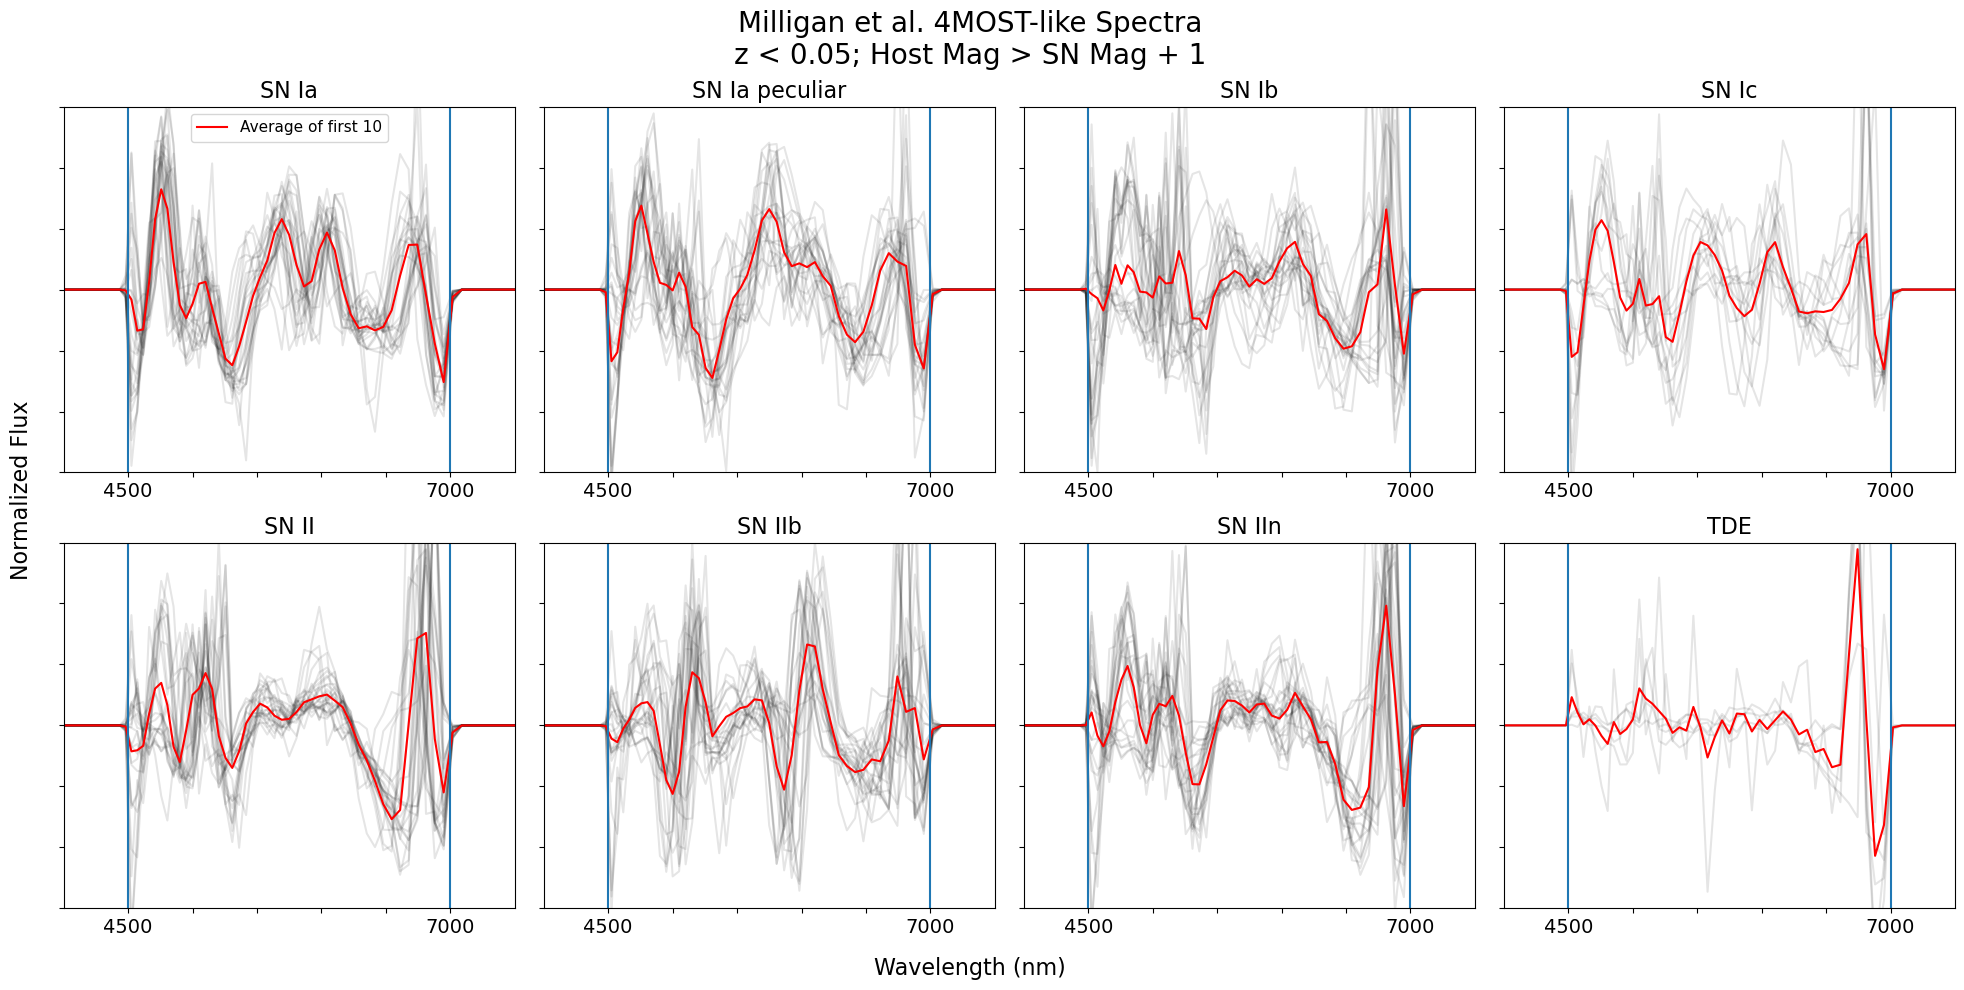

In [8]:
types = ['Ia', 'Iap', 'Ib',   'Ic', 'II', 'IIb', 'IIn', "TDE"]
types_titles = ['SN Ia', 'SN Ia peculiar', 'SN Ib',   'SN Ic', 'SN II', 'SN IIb', 'SN IIn', 'TDE']
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration
brighter_SN_index = master_df.host_mag > master_df.SN_mag +1
small_z_index = master_df.redshift < 0.05
close_bright_df = master_df[small_z_index] #df[brighter_SN_index & small_z_index]
num_wvl = 139
flux_start, flux_stop = 59, 103


for j, sn_type in enumerate(types):
    ax = axes[j]
    temp_df = close_bright_df[close_bright_df.sn_type == sn_type]
    
    dat_size = len(temp_df)
    X_temp = np.zeros((num_wvl, ))

    for n, i in enumerate(temp_df.index.values):
        if n < 10:
            X_temp += X_all[i]
        if n < 25:
            ax.plot(wvl, X_all[i], alpha = 0.1, color = "k")

    if dat_size < 10:
        ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
    else:
        ax.plot(wvl, X_temp/10 , alpha = 1, color = "r", label="Average of first 10")
    ax.set_title(f"{types_titles[j]}", fontsize = 16)
    ax.set_ylim(-3, 3)
    ax.set_xlim(4000,7500)
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels(['', '', '', '', '', ''])
    ax.set_yticks([-3,-2,-1, 0, 1,2,3])
    ax.set_yticklabels(["", "", " ", " ", "", "", "" ])
    if j == 0:
        ax.legend()
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels([4500, '', '', '', '', 7000], fontsize = 14)

    ax.axvline(4500)
    ax.axvline(7000)

fig.suptitle("Milligan et al. 4MOST-like Spectra\nz < 0.05; Host Mag > SN Mag + 1", fontsize =20)

fig.supxlabel("Wavelength (nm)", fontsize = 16)
fig.supylabel("Normalized Flux\n", fontsize = 16)
plt.savefig("small_z_.png")

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.savefig("small_z_.png")

Artifacts on edges?